In [1]:
import numpy as np
import matplotlib.pyplot as plt

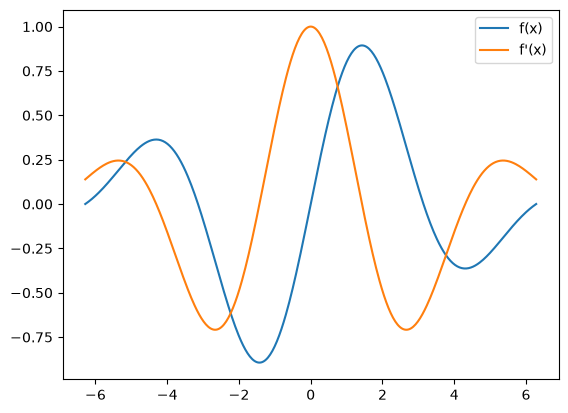

In [9]:
x = np.linspace(-2*np.pi, 2*np.pi, 401)
fx = np.sin(x) * np.exp(-x**2*0.05)

# derivative 
df = np.cos(x)*np.exp(-x**2*0.05) + np.sin(x)*(-.1*x)*np.exp(-x**2*0.05)

plt.plot(x, fx, x, df)
plt.legend(["f(x)", "f'(x)"])
plt.show()

In [10]:
def fx(x):
    return np.sin(x) * np.exp(-x**2*0.05)

def deriv(x):
    return np.cos(x)*np.exp(-x**2*0.05) + np.sin(x)*(-.1*x)*np.exp(-x**2*0.05)

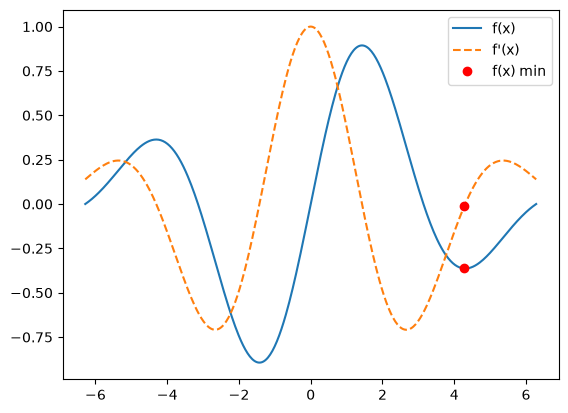

In [14]:
local_min = np.random.choice(x, 1)

lr = 0.01
epochs = 1000

for i in range(epochs):
    grad = deriv(local_min)
    local_min = local_min -lr * grad


plt.plot(x, fx(x), x, deriv(x), '--')
plt.plot(local_min, fx(local_min), 'ro')
plt.plot(local_min, deriv(local_min), 'ro')
plt.legend(["f(x)", "f'(x)", "f(x) min"])
plt.show()

#### As we see in the above graph from the graph above we are stuck with the local minimum

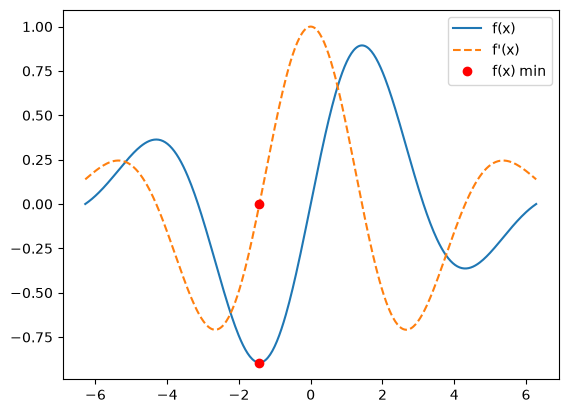

In [17]:
local_min = np.random.choice(x, 1)

lr = 0.01
epochs = 1000

for i in range(epochs):
    grad = deriv(local_min)
    local_min = local_min -lr * grad


plt.plot(x, fx(x), x, deriv(x), '--')
plt.plot(local_min, fx(local_min), 'ro')
plt.plot(local_min, deriv(local_min), 'ro')
plt.legend(["f(x)", "f'(x)", "f(x) min"])
plt.show()

#### Ans now with erandom startting point we reached the global minima this is completely random!!

### Play with different starting locations

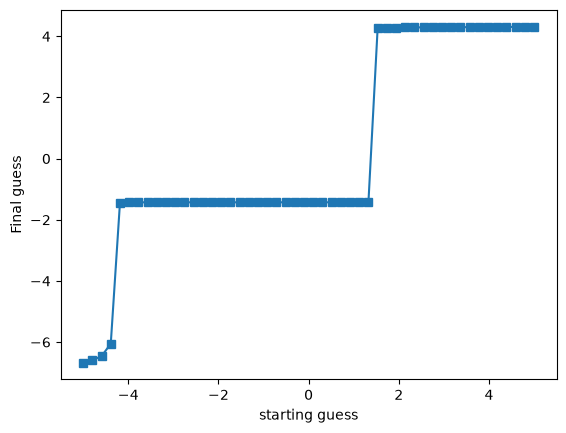

In [22]:
startlocs = np.linspace(-5, 5, 50)
finalres = np.zeros(len(startlocs))
lr = 0.01

for idx, local_min in enumerate(startlocs):
    for i in range(epochs):
        grad = deriv(local_min)
        local_min = local_min - lr*grad
    finalres[idx] = local_min


plt.plot(startlocs, finalres, 's-')
plt.xlabel('starting guess')
plt.ylabel('Final guess')
plt.show()

#### So now we know that thefinal result is reached when we start between -2 to 0 from the graph

### Sytematically varying the learning rate

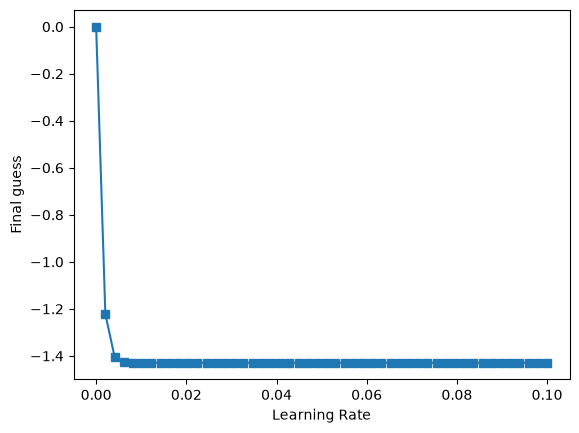

In [25]:
lr_s = np.linspace(1e-10, 1e-1, 50)
finalres = np.zeros(len(lr_s))

for idx, lr in enumerate(lr_s):
    local_min = 0

    for i in range(epochs):
        grad = deriv(local_min)
        local_min = local_min - lr*grad

    finalres[idx] = local_min


plt.plot(lr_s, finalres, 's-')
plt.xlabel('Learning Rate')
plt.ylabel('Final guess')
plt.show()

### Interaction between learning rate and training epochs

In [37]:
lr_s = np.linspace(1e-10, 1e-1, 50)
epochs = np.round(np.linspace(10, 500, 40))

finalres = np.zeros((len(lr_s), len(epochs)))

for lidx, lr in enumerate(lr_s):
    for eidx, epoch in enumerate(epochs):
        local_min = 0
        for i in range(int(epoch)):
            grad = deriv(local_min)
            local_min = local_min - lr*grad
        finalres[lidx, eidx] = local_min

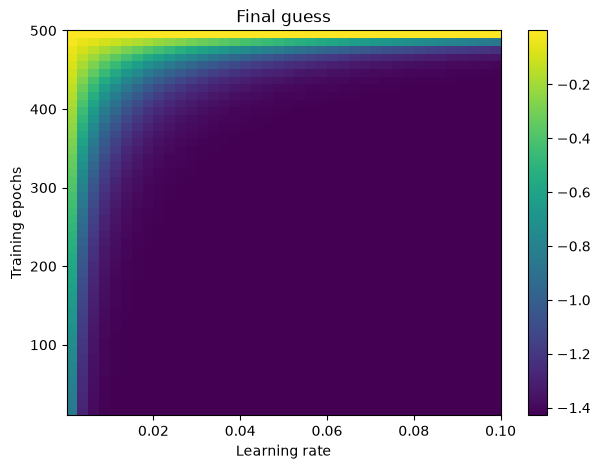

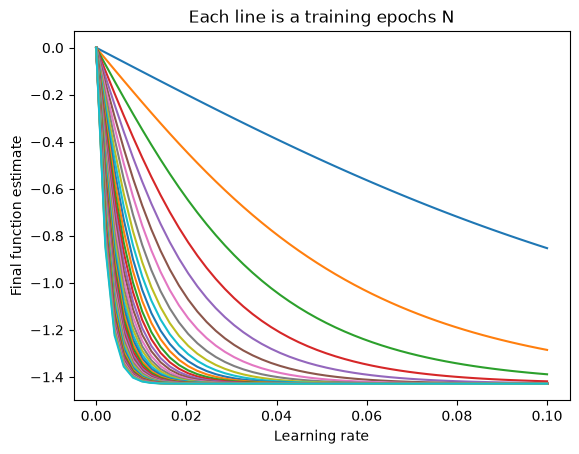

In [38]:
fig, ax = plt.subplots(figsize=(7,5))

plt.imshow(finalres, extent=[lr_s[0], lr_s[-1], epochs[0], epochs[-1]], aspect='auto')

plt.xlabel('Learning rate')
plt.ylabel('Training epochs')
plt.title('Final guess')
plt.colorbar()
plt.show()


plt.plot(lr_s, finalres)
plt.xlabel('Learning rate')
plt.ylabel('Final function estimate')
plt.title('Each line is a training epochs N')
plt.show()
